copio soluzione analitica e stifness analysis dal foglio di appunti.

In [65]:
import numpy as np
import methods as m 
import integrate as integ
import matplotlib.pyplot as plt

In [66]:
def df_dt(t, y, args=None):
    u_new = 998*y[0] + 1998*y[1]
    v_new = -999*y[0] - 1999*y[1]
    return np.array([u_new, v_new])

def u_true(t):
    return 2*np.exp(-t) - np.exp(-1000*t)

def v_true(t):
    return -np.exp(-t) + np.exp(-1000*t)

## Forward Euler (explicit, order 1). 

Implement and integrate from t = 0 to t = 5.

(i) Use h = 0.003 (above the stability limit). Observe the blow-up and explain it using
the eigenvalues and the stability region from Exercise 1.

(ii) Use h = 0.001 (below the stability limit). Confirm the solution is now stable. How
many steps are needed? Compare with the number of steps that would suffice for
accuracy if stability were not a constraint.

In [67]:
h = 0.003
t0 = 0
tf = 5

t_range = (t0, tf)

u_0 = 1
v_0 = 0

IC = np.array([u_0, v_0])

[0.000e+00 3.000e-03 6.000e-03 ... 4.995e+00 4.998e+00 5.000e+00]
[[ 1.        0.      ]
 [ 3.994    -2.997   ]
 [-2.011982  3.005991]
 ...
 [      nan       nan]
 [      nan       nan]
 [      nan       nan]]


/tmp/ipykernel_2477/1064926198.py:2: RuntimeWarning: overflow encountered in scalar multiply
  u_new = 998*y[0] + 1998*y[1]
/tmp/ipykernel_2477/1064926198.py:3: RuntimeWarning: overflow encountered in scalar multiply
  v_new = -999*y[0] - 1999*y[1]
/tmp/ipykernel_2477/1064926198.py:2: RuntimeWarning: invalid value encountered in scalar add
  u_new = 998*y[0] + 1998*y[1]
/tmp/ipykernel_2477/1064926198.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  v_new = -999*y[0] - 1999*y[1]


(-100000.0, 100000.0)

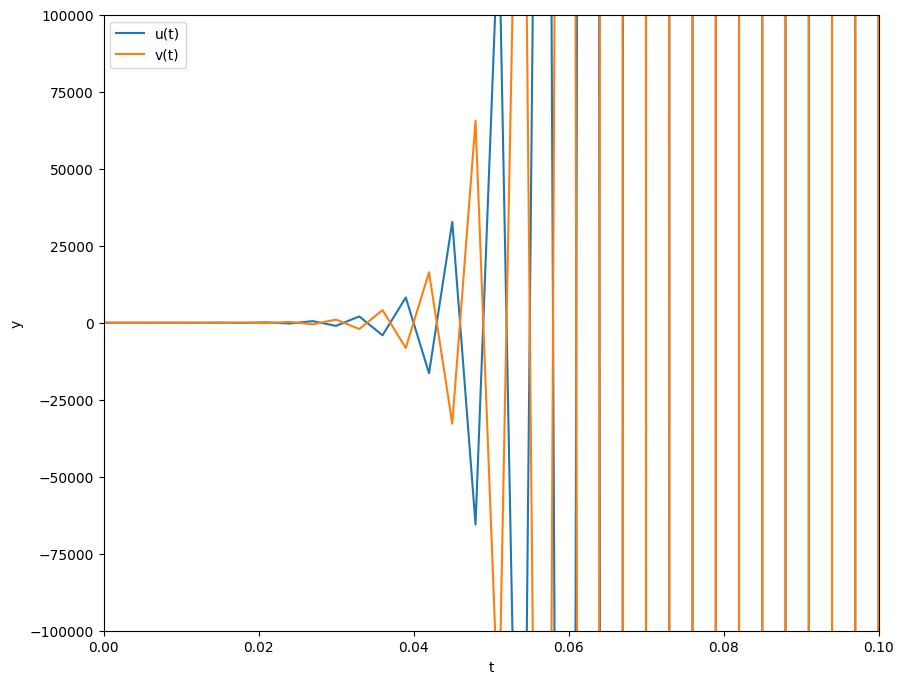

In [68]:
t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.forward_euler)

print (t)
print (y)

fig, ax = plt.subplots(figsize=(10,8))

ax.set_xlabel('t')
ax.set_ylabel('y')

ax.plot(t, y[:, 0], label='u(t)')
ax.plot(t, y[:, 1], label='v(t)')

ax.legend()
ax.set_xlim(0, 0.1)
ax.set_ylim(-1e5, 1e5)

inserisco spiegazione per bene sulla stability

In [69]:
h = 0.001


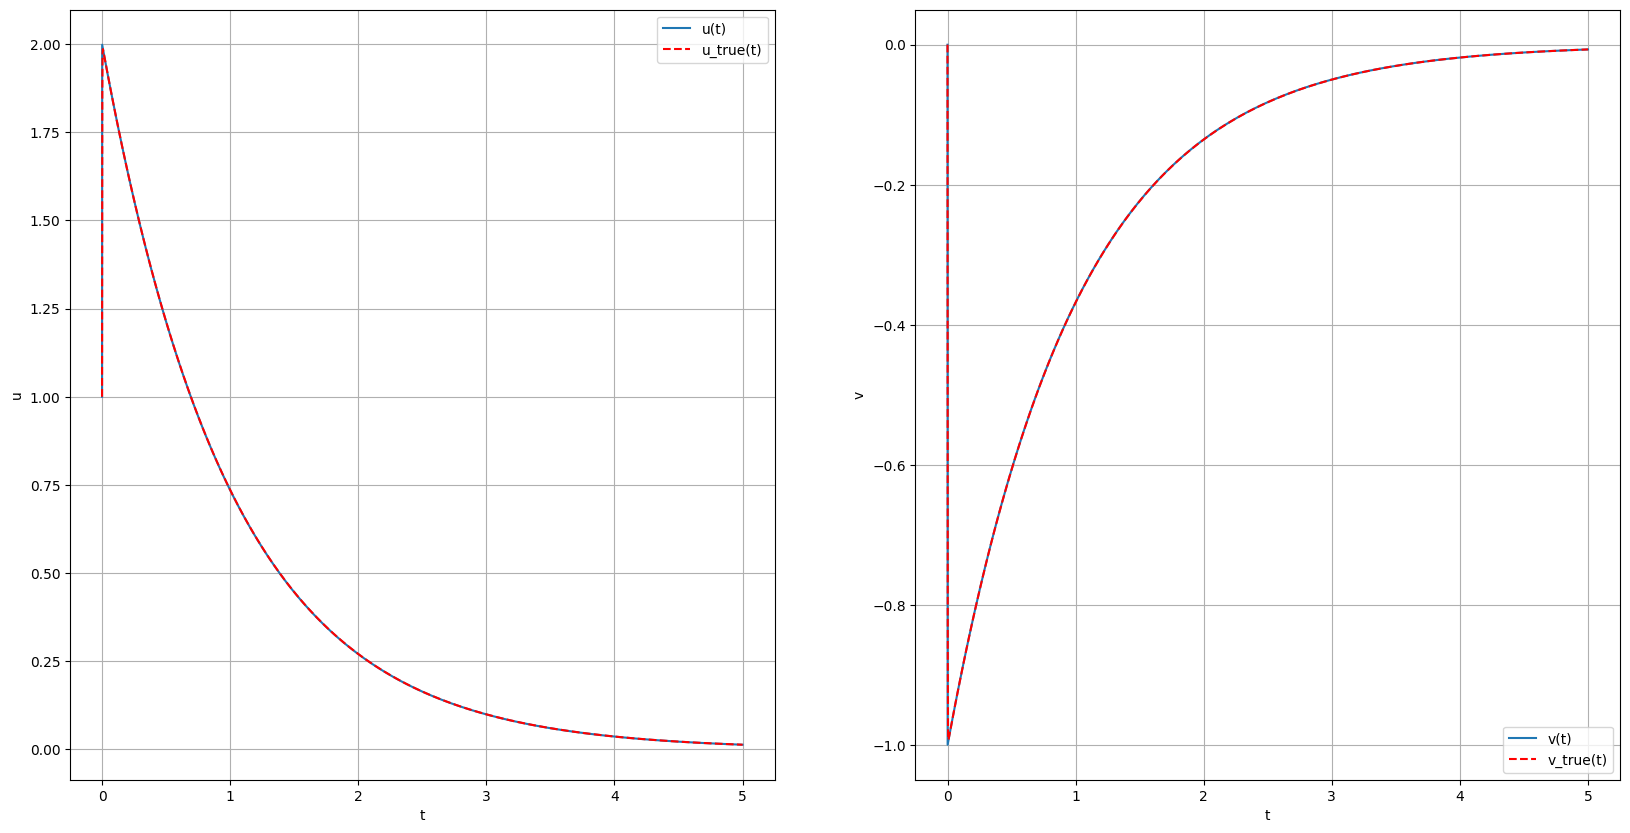

In [73]:
t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.forward_euler)

u_values = u_true(t)
v_values = v_true(t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.set_xlabel('t')
ax1.set_ylabel('u')
ax1.plot(t, y[:, 0], label='u(t)')
ax1.plot(t, u_values, label='u_true(t)', linestyle='dashed', color='red')
ax1.legend()
ax1.grid()

ax2.set_xlabel('t')
ax2.set_ylabel('v')
ax2.plot(t, y[:, 1], label='v(t)')
ax2.plot(t, v_values, label='v_true(t)', linestyle='dashed', color='red')
ax2.legend()
ax2.grid()

In [75]:
print(f"sono stati necessari {len(t)} step")

sono stati necessari 5001 step


Nel caso in cui avessimo usato solo la h_acc di 0.05 avremmo fatto solo 100 step, molti meno computazionalmente parlando.

## Explicit Midpoint (explicit, order 2). 

Repeat the experiment with h = 0.003 and h =
0.001.

Is the stability limit significantly different from forward Euler? Does the higher
order help with the stiffness problem?


/tmp/ipykernel_2477/1064926198.py:2: RuntimeWarning: overflow encountered in scalar multiply
  u_new = 998*y[0] + 1998*y[1]
/tmp/ipykernel_2477/1064926198.py:3: RuntimeWarning: overflow encountered in scalar multiply
  v_new = -999*y[0] - 1999*y[1]
/tmp/ipykernel_2477/1064926198.py:2: RuntimeWarning: invalid value encountered in scalar add
  u_new = 998*y[0] + 1998*y[1]
/tmp/ipykernel_2477/1064926198.py:3: RuntimeWarning: invalid value encountered in scalar subtract
  v_new = -999*y[0] - 1999*y[1]


[0.000e+00 3.000e-03 6.000e-03 ... 4.995e+00 4.998e+00 5.000e+00]
[[ 1.          0.        ]
 [-0.505991    1.5029955 ]
 [-4.26196405  5.25598203]
 ...
 [        nan         nan]
 [        nan         nan]
 [        nan         nan]]


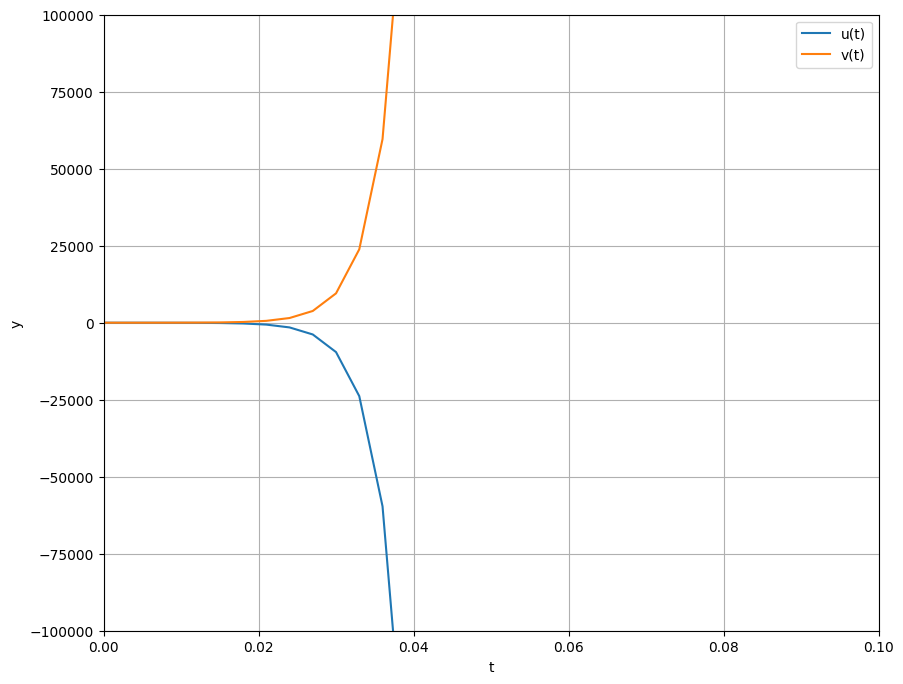

In [86]:
h = 0.003

t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.explicit_midpoint)

print (t)
print (y)

fig, ax = plt.subplots(figsize=(10,8))

ax.set_xlabel('t')
ax.set_ylabel('y')

ax.plot(t, y[:, 0], label='u(t)')
ax.plot(t, y[:, 1], label='v(t)')

ax.legend()
ax.set_xlim(0, 0.1)
ax.set_ylim(-1e5, 1e5)
ax.grid()

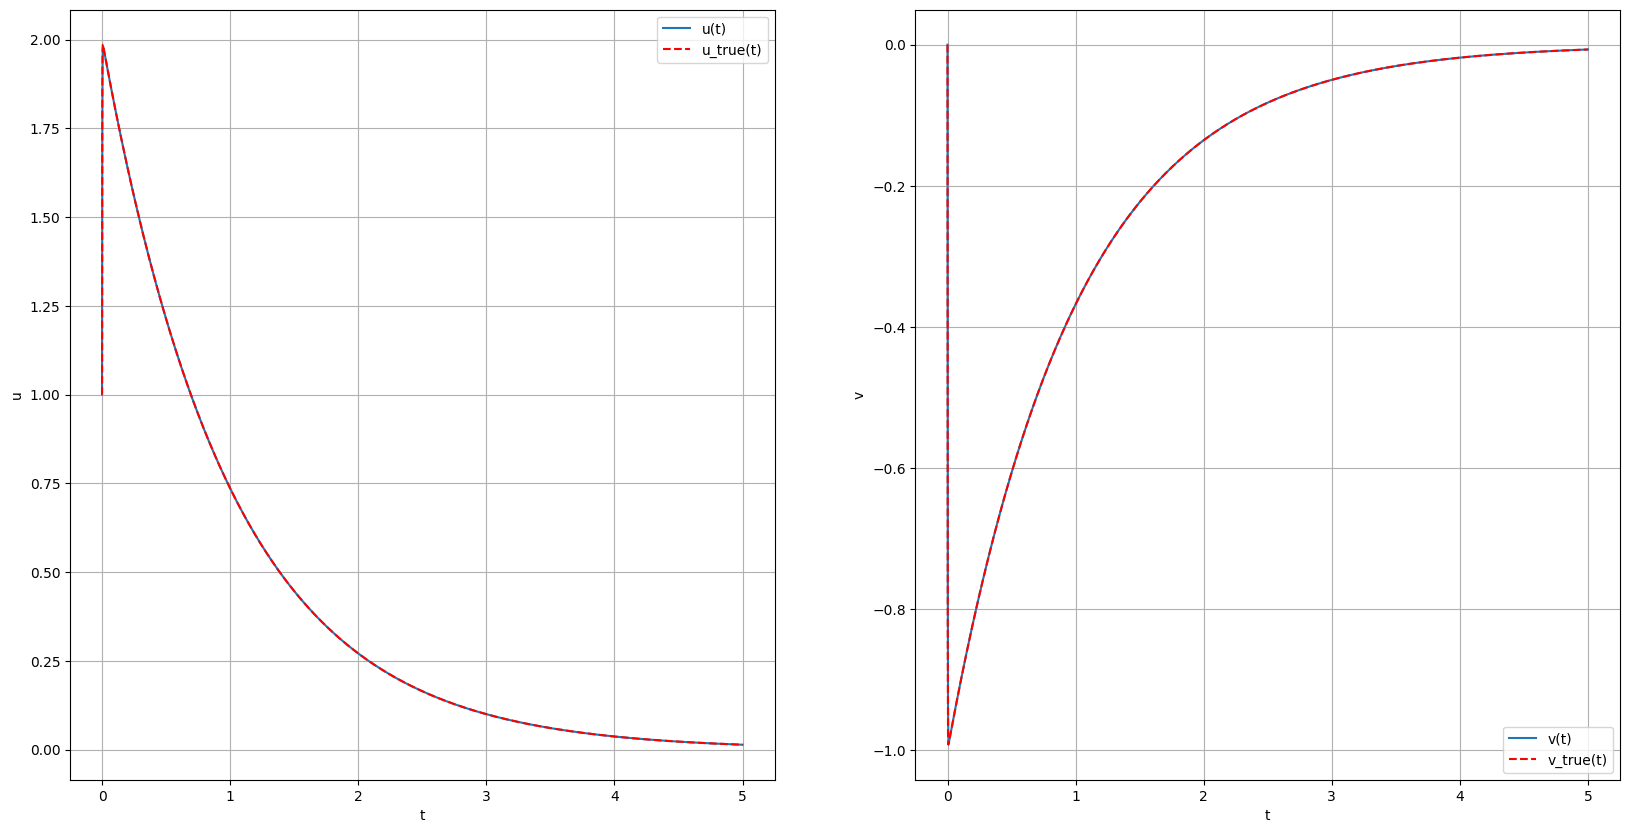

In [87]:
h = 0.001

t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.explicit_midpoint)

u_values = u_true(t)
v_values = v_true(t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.set_xlabel('t')
ax1.set_ylabel('u')
ax1.plot(t, y[:, 0], label='u(t)')
ax1.plot(t, u_values, label='u_true(t)', linestyle='dashed', color='red')
ax1.legend()
ax1.grid()

ax2.set_xlabel('t')
ax2.set_ylabel('v')
ax2.plot(t, y[:, 1], label='v(t)')
ax2.plot(t, v_values, label='v_true(t)', linestyle='dashed', color='red')
ax2.legend()
ax2.grid()

devo confrontarli un po' ma l'idea è che esplode lo stesso un poco dopo ma esplode uguale se sto sopra lo stability limit.

ora faccio i metodi impliciti, cheide quella cosa di invertire la matrice

## Backward Euler (implicit, order 1).

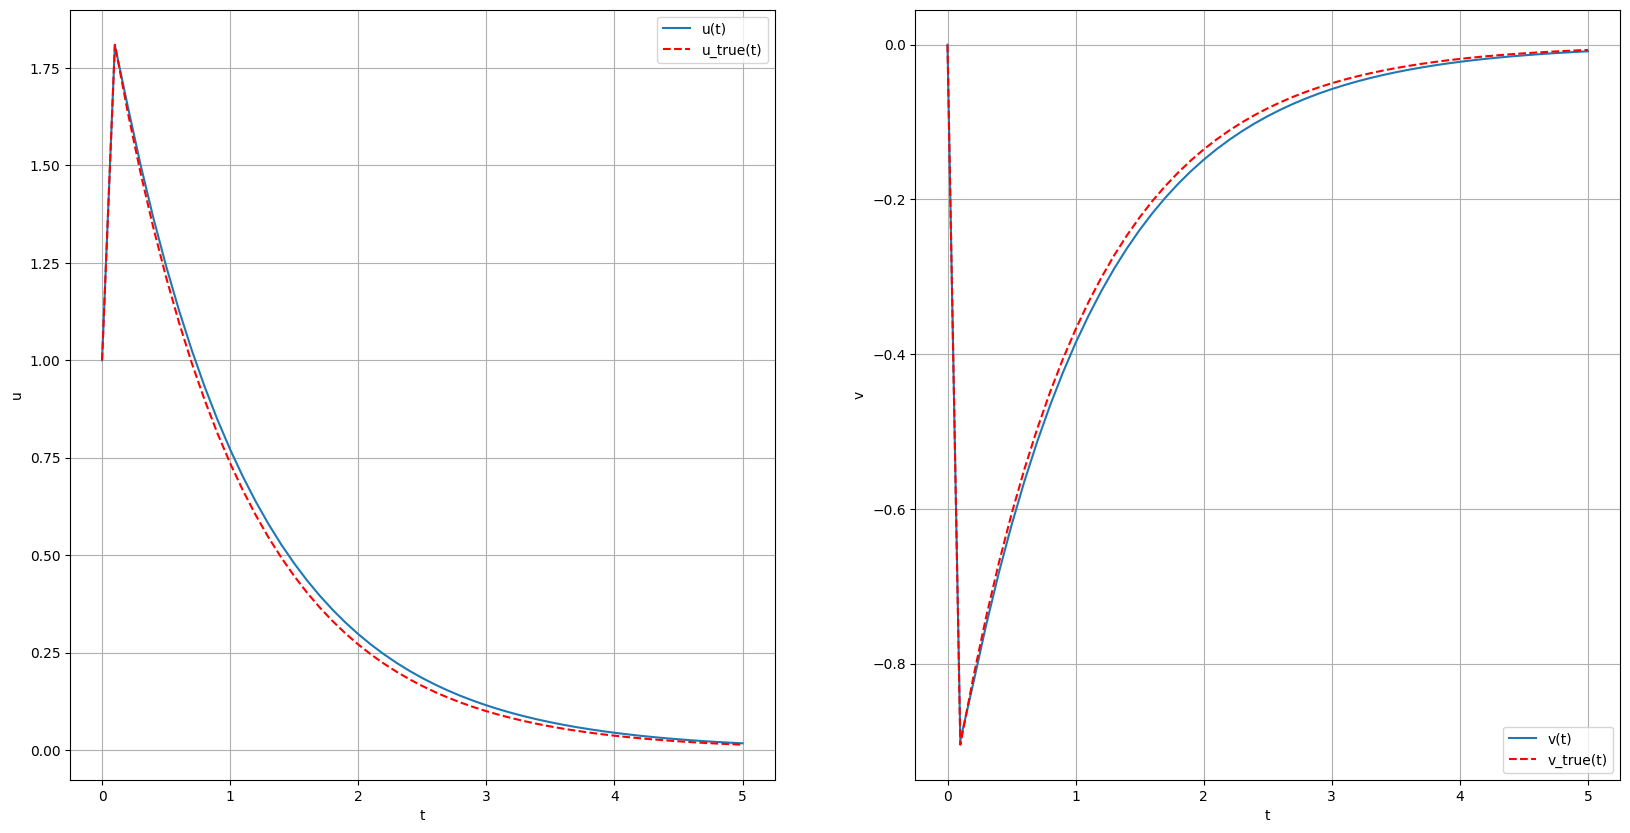

In [90]:
h = 0.1

t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.backward_euler)


u_values = u_true(t)
v_values = v_true(t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.set_xlabel('t')
ax1.set_ylabel('u')
ax1.plot(t, y[:, 0], label='u(t)')
ax1.plot(t, u_values, label='u_true(t)', linestyle='dashed', color='red')
ax1.legend()
ax1.grid()

ax2.set_xlabel('t')
ax2.set_ylabel('v')
ax2.plot(t, y[:, 1], label='v(t)')
ax2.plot(t, v_values, label='v_true(t)', linestyle='dashed', color='red')
ax2.legend()
ax2.grid()

/tmp/ipykernel_2477/3340625185.py:2: RuntimeWarning: invalid value encountered in divide
  errors = (y - np.array([u_values, v_values]).T) / np.array([u_values, v_values]).T


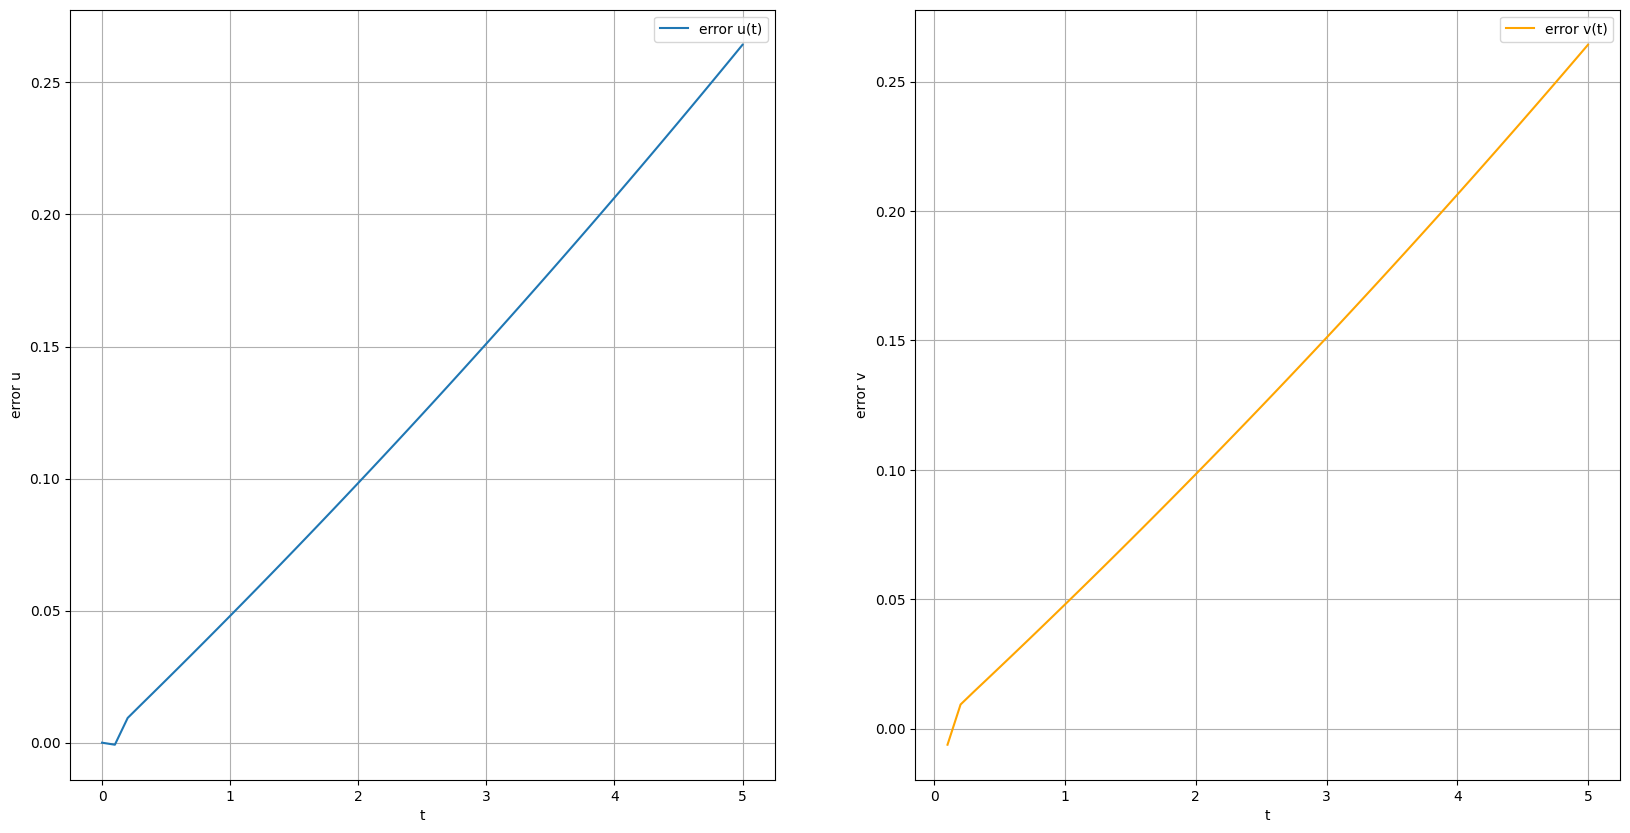

In [ ]:
#non so bene cosa mi aspetto, ma il fatto che non esploda non è male 
errors = np.abs((y - np.array([u_values, v_values]).T) / np.array([u_values, v_values]).T)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.set_xlabel('t')
ax1.set_ylabel('error u')
ax1.plot(t, errors[:, 0], label='error u(t)')
ax1.legend()
ax1.grid()
ax2.set_xlabel('t')
ax2.set_ylabel('error v')
ax2.plot(t, errors[:, 1], label='error v(t)', color='orange')
ax2.legend()
ax2.grid()

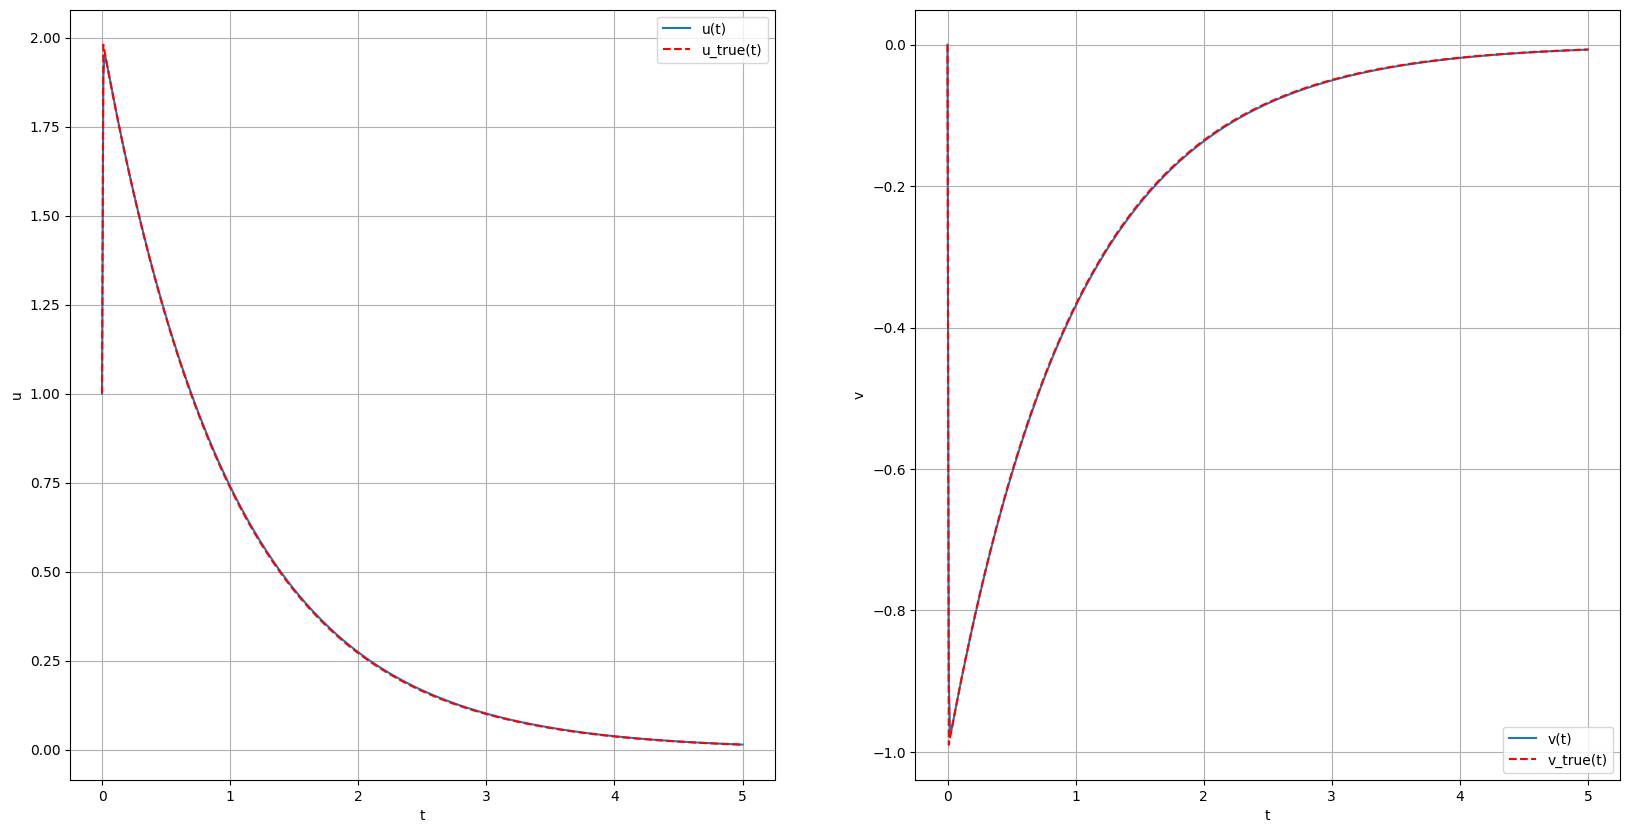

In [93]:
h = 0.01

t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.backward_euler)


u_values = u_true(t)
v_values = v_true(t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.set_xlabel('t')
ax1.set_ylabel('u')
ax1.plot(t, y[:, 0], label='u(t)')
ax1.plot(t, u_values, label='u_true(t)', linestyle='dashed', color='red')
ax1.legend()
ax1.grid()

ax2.set_xlabel('t')
ax2.set_ylabel('v')
ax2.plot(t, y[:, 1], label='v(t)')
ax2.plot(t, v_values, label='v_true(t)', linestyle='dashed', color='red')
ax2.legend()
ax2.grid()

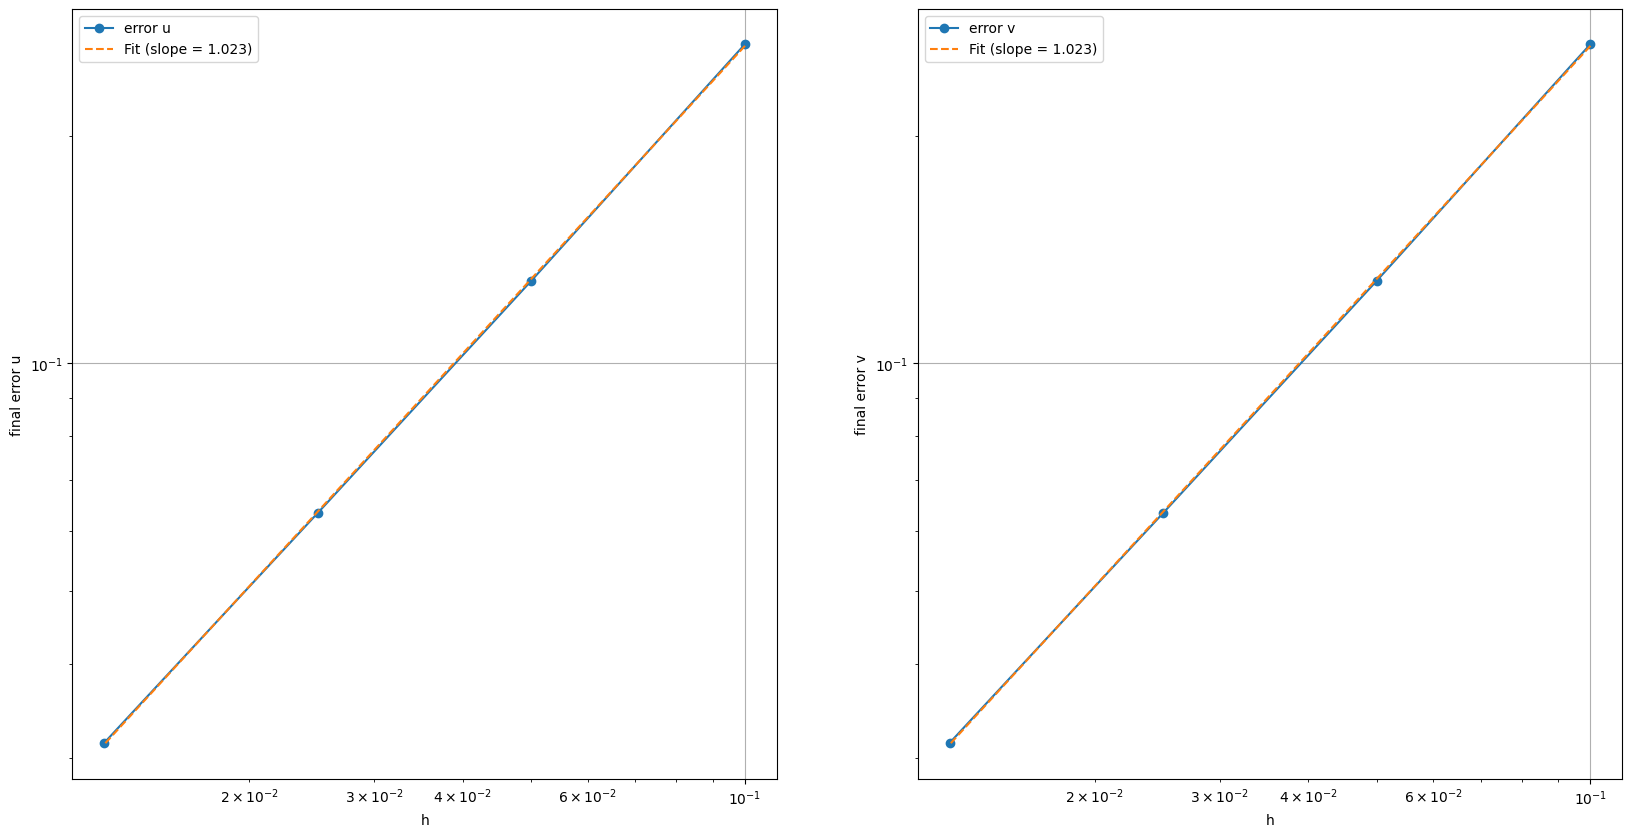

In [99]:
h = 0.1
final_errors = []
u_end = u_true(tf)
v_end = v_true(tf)
final_pos = np.array([u_end, v_end])
while h > 0.01:
    t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.backward_euler)
    final_errors.append((y[-1] - final_pos)/final_pos)

    h /= 2

final_errors = np.array(final_errors)
hs = np.array(0.1 / (2**np.arange(len(final_errors))))

slope_u, intercept_u = np.polyfit(np.log(hs), np.log(final_errors[:, 0]), 1)
u_line = np.exp(intercept_u) * (hs ** slope_u)

slope_v, intercept_v = np.polyfit(np.log(hs), np.log(final_errors[:, 1]), 1)
v_line = np.exp(intercept_v) * (hs ** slope_v)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.set_xlabel('h')
ax1.set_ylabel('final error u')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.plot(hs, final_errors[:, 0], label='error u', marker='o')
ax1.plot(hs, u_line, label=f'Fit (slope = {slope_u:.3f})', linestyle='--')
ax1.legend()
ax1.grid()

ax2.set_xlabel('h')
ax2.set_ylabel('final error v')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.plot(hs, final_errors[:, 1], label='error v', marker='o')
ax2.plot(hs, v_line, label=f'Fit (slope = {slope_v:.3f})', linestyle='--')
ax2.legend()
ax2.grid()

## implicit midpoint (implicit, order 2).

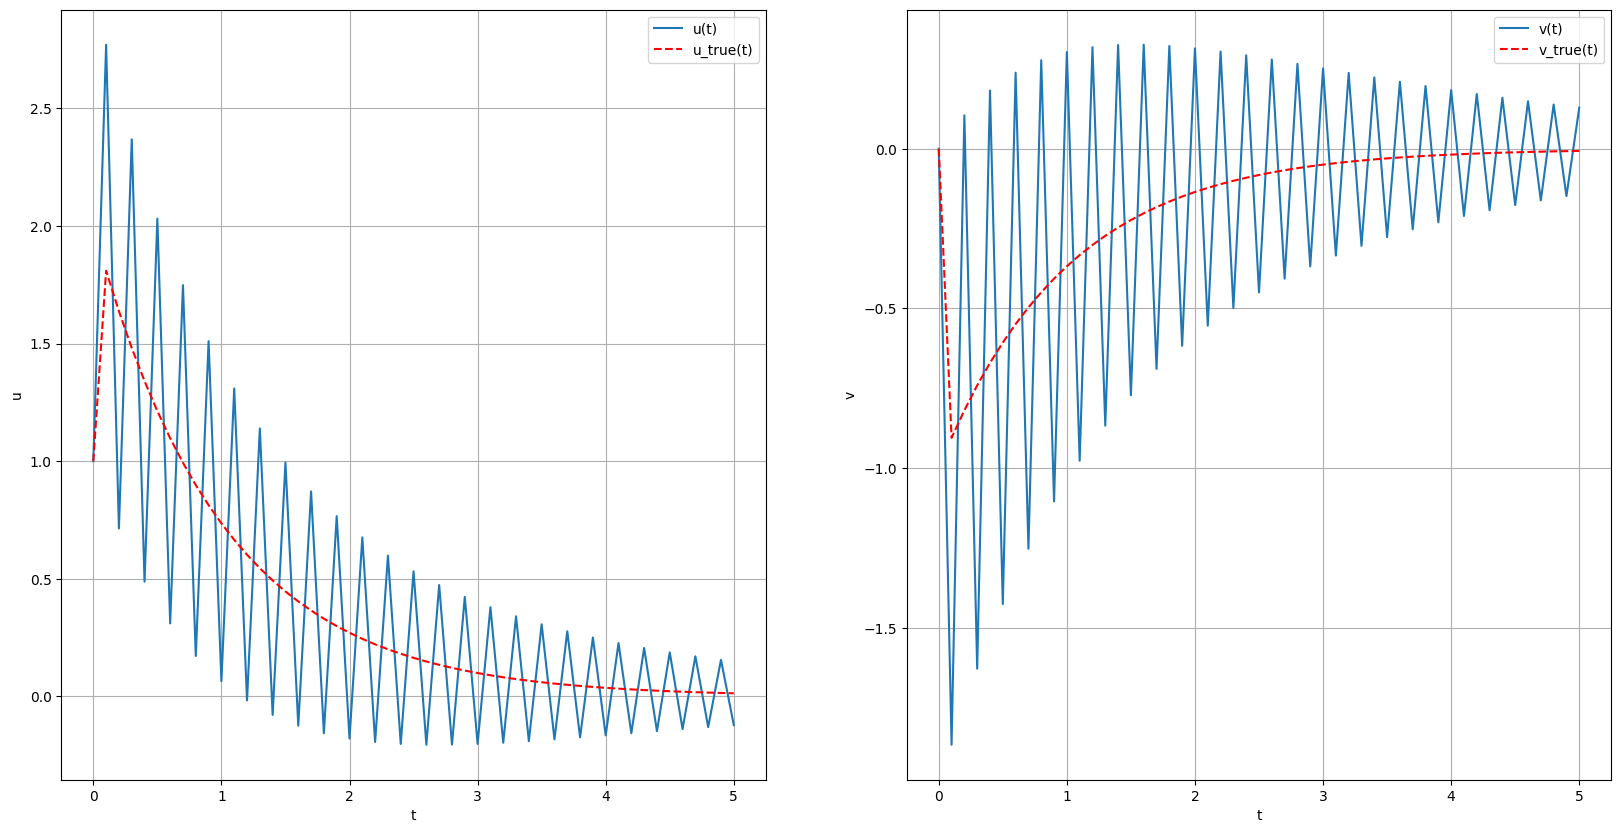

In [114]:
h = 0.1

t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.implicit_midpoint)


u_values = u_true(t)
v_values = v_true(t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.set_xlabel('t')
ax1.set_ylabel('u')
ax1.plot(t, y[:, 0], label='u(t)')
ax1.plot(t, u_values, label='u_true(t)', linestyle='dashed', color='red')
ax1.legend()
ax1.grid()

ax2.set_xlabel('t')
ax2.set_ylabel('v')
ax2.plot(t, y[:, 1], label='v(t)')
ax2.plot(t, v_values, label='v_true(t)', linestyle='dashed', color='red')
ax2.legend()
ax2.grid()

/tmp/ipykernel_2477/3251780091.py:2: RuntimeWarning: invalid value encountered in divide
  errors = np.abs((y - np.array([u_values, v_values]).T) / np.array([u_values, v_values]).T)


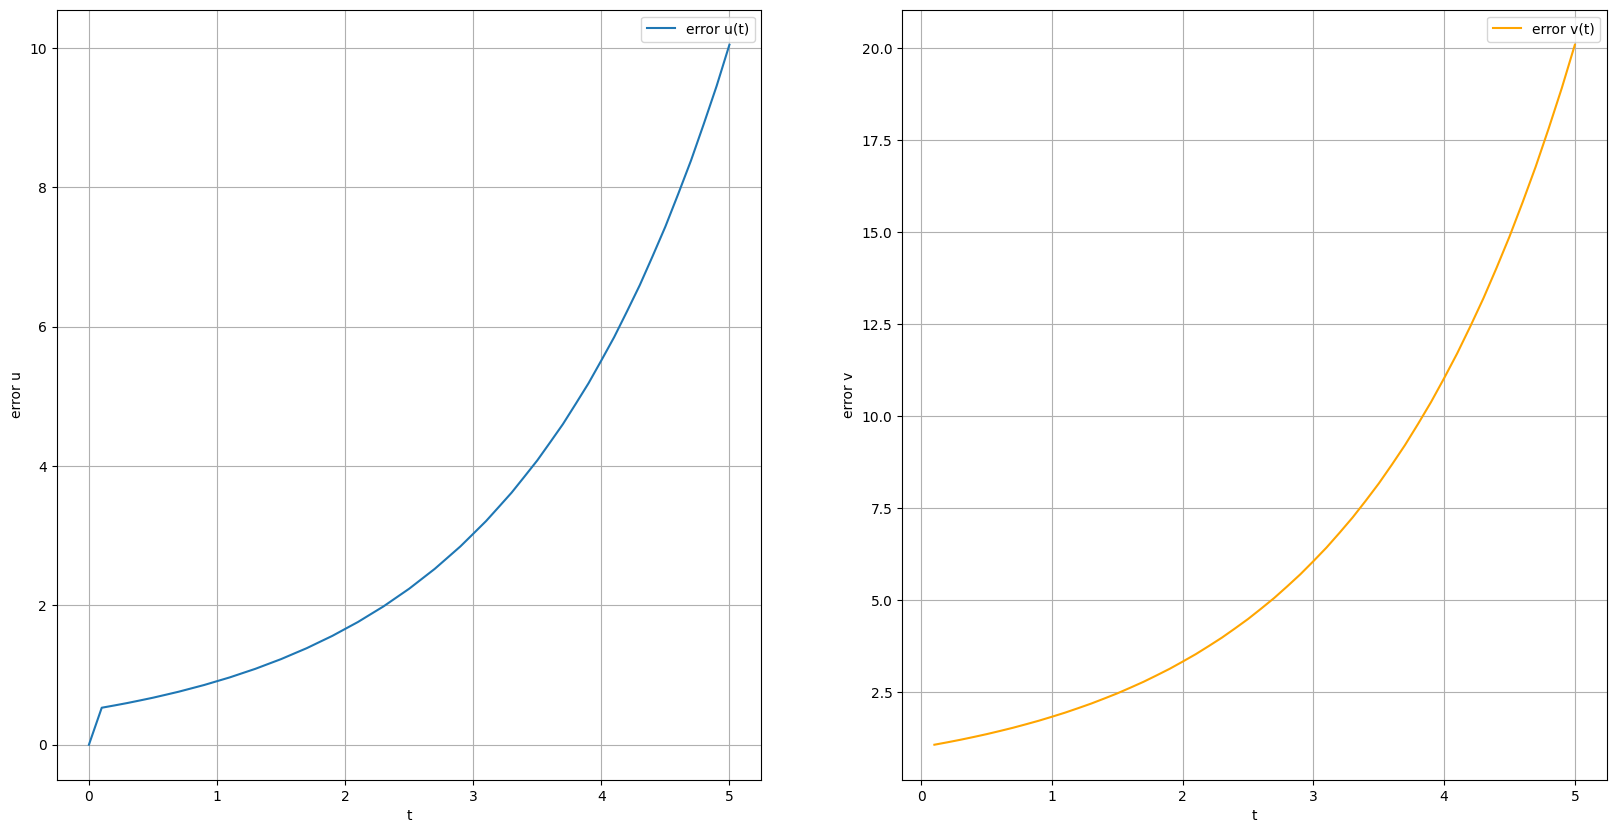

In [115]:
#non so bene cosa mi aspetto, ma il fatto che non esploda non è male 
errors = np.abs((y - np.array([u_values, v_values]).T) / np.array([u_values, v_values]).T)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.set_xlabel('t')
ax1.set_ylabel('error u')
ax1.plot(t, errors[:, 0], label='error u(t)')
ax1.legend()
ax1.grid()
ax2.set_xlabel('t')
ax2.set_ylabel('error v')
ax2.plot(t, errors[:, 1], label='error v(t)', color='orange')
ax2.legend()
ax2.grid()

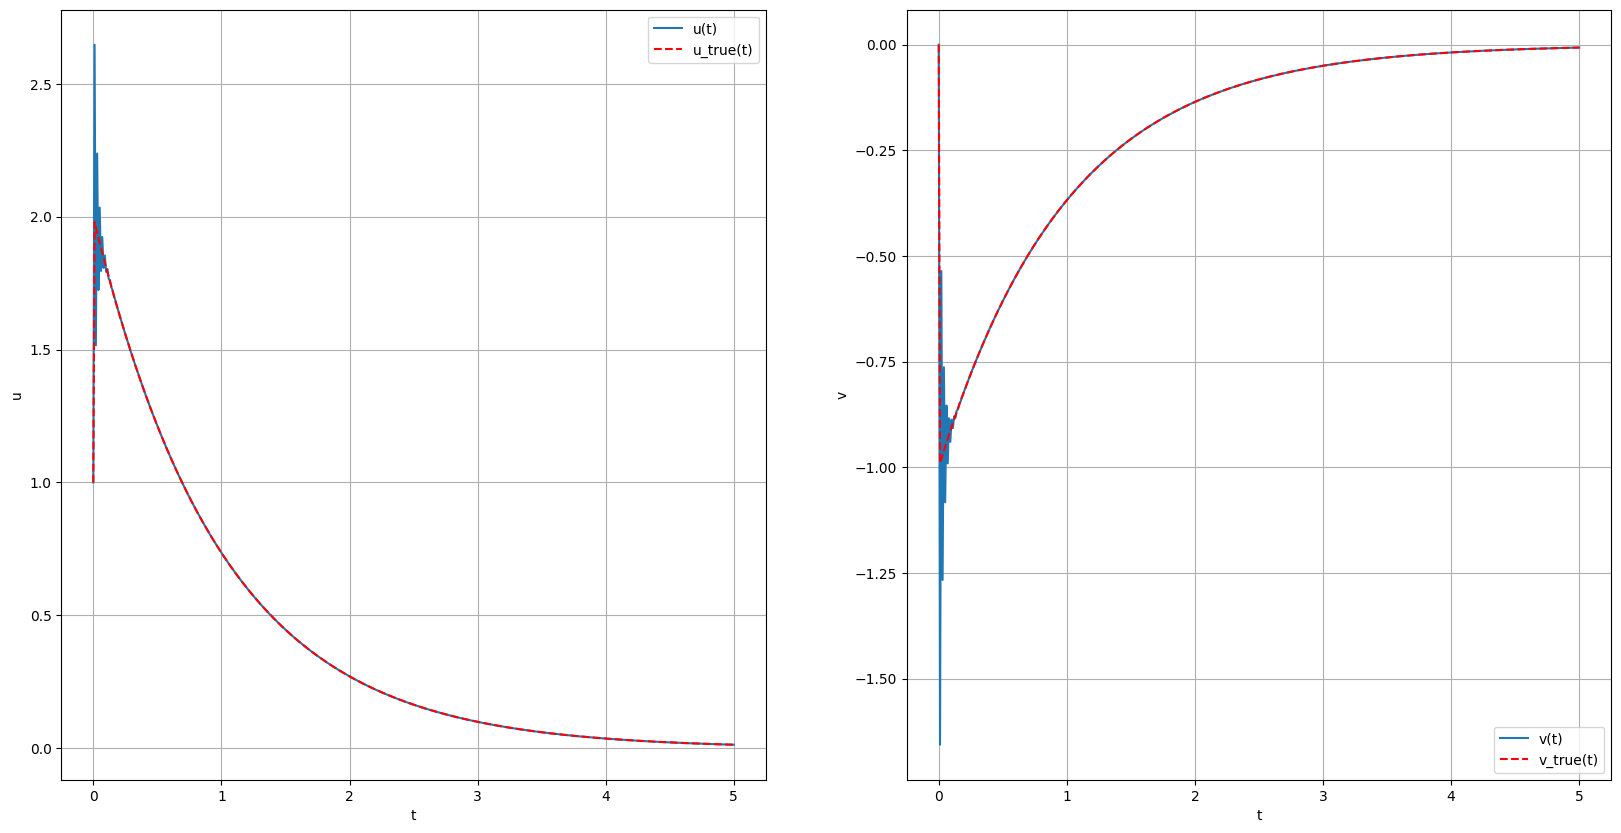

In [116]:
h = 0.01

t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.implicit_midpoint)


u_values = u_true(t)
v_values = v_true(t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.set_xlabel('t')
ax1.set_ylabel('u')
ax1.plot(t, y[:, 0], label='u(t)')
ax1.plot(t, u_values, label='u_true(t)', linestyle='dashed', color='red')
ax1.legend()
ax1.grid()

ax2.set_xlabel('t')
ax2.set_ylabel('v')
ax2.plot(t, y[:, 1], label='v(t)')
ax2.plot(t, v_values, label='v_true(t)', linestyle='dashed', color='red')
ax2.legend()
ax2.grid()

h: 0.1, error: [10.04425434 20.08434444]
h: 0.05, error: [0.02582896 0.05061641]
h: 0.025, error: [0.00026041 0.00026041]
h: 0.0125, error: [6.51035732e-05 6.51035732e-05]
h: 0.00625, error: [1.62760046e-05 1.62760046e-05]
h: 0.003125, error: [4.06900823e-06 4.06900823e-06]
h: 0.0015625, error: [1.01725243e-06 1.01725243e-06]


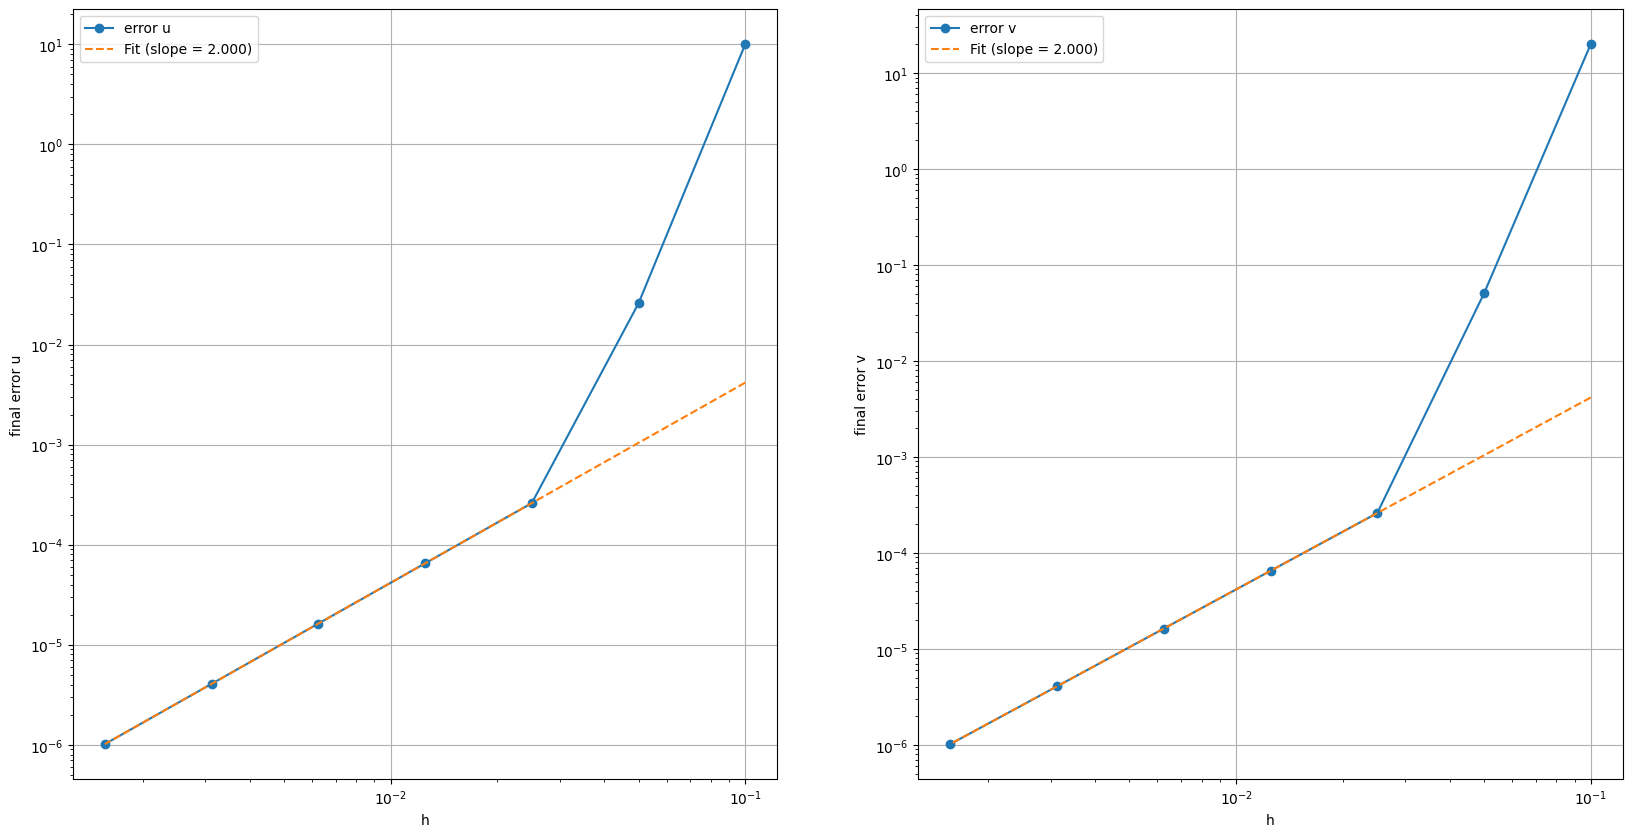

In [124]:
h = 0.1
final_errors = []
u_end = u_true(tf)
v_end = v_true(tf)
final_pos = np.array([u_end, v_end])
while h > 0.001:
    t, y = integ.integrate(df_dt, t_range, IC, h, args=None, method=m.implicit_midpoint)
    final_errors.append(np.abs((y[-1] - final_pos)/final_pos))
    print(f"h: {h}, error: {final_errors[-1]}")

    h /= 2

final_errors = np.array(final_errors)
hs = np.array(0.1 / (2**np.arange(len(final_errors))))

slope_u, intercept_u = np.polyfit(np.log(hs[2:]), np.log(final_errors[2:, 0]), 1)
u_line = np.exp(intercept_u) * (hs ** slope_u)

slope_v, intercept_v = np.polyfit(np.log(hs[2:]), np.log(final_errors[2:, 1]), 1)
v_line = np.exp(intercept_v) * (hs ** slope_v)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.set_xlabel('h')
ax1.set_ylabel('final error u')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.plot(hs, final_errors[:, 0], label='error u', marker='o')
ax1.plot(hs, u_line, label=f'Fit (slope = {slope_u:.3f})', linestyle='--')
ax1.legend()
ax1.grid()

ax2.set_xlabel('h')
ax2.set_ylabel('final error v')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.plot(hs, final_errors[:, 1], label='error v', marker='o')
ax2.plot(hs, v_line, label=f'Fit (slope = {slope_v:.3f})', linestyle='--')
ax2.legend()
ax2.grid()

con h troppo grande sbarella forte ma poi va bene, si gode